In [1]:
import scipy as sc
import numpy as np

In [17]:
#uniform attention weight
a = np.array([0.25, 0.25, 0.25, 0.25]).reshape(4, 1)
#T matrix 4 by 2
T = np.array([[1.4, 0.2], [0.5, 1.5], [-1.2, 0.9], [0.1, 0.8]])

output= a.T @ T
print(output)

T_aug = np.array([[1.4, 0.2, 1], [0.5, 1.5,1], [-1.2, 0.9,1], [0.1, 0.8,1]])
basis_LN = sc.null_space(T_aug.T)
print(basis_LN)

lam_list = []
for idx, i in enumerate(basis_LN):
    if i < 0:
        lam = -a[idx]/basis_LN[idx]
        lam_list.append(lam)

lam_max = np.min(lam_list)
print(lam_max)

lam_a_tilde = np.array(lam_max*basis_LN)
print(lam_a_tilde)

print((a + lam_a_tilde).T @ T_aug)
print(a + lam_a_tilde, np.sum(a+lam_a_tilde))

[[0.2  0.85]]
[[-0.29731083]
 [-0.2034232 ]
 [-0.35990259]
 [ 0.86063662]]
0.6946324047248027
[[-0.20652174]
 [-0.14130435]
 [-0.25      ]
 [ 0.59782609]]
[[0.2  0.85 1.  ]]
[[0.04347826]
 [0.10869565]
 [0.        ]
 [0.84782609]] 1.0000000000000002


In [24]:
# Negative LN vector

print(-basis_LN)

neg_basis_LN = -basis_LN

lam_list = []
for idx, i in enumerate(neg_basis_LN):
    if i < 0:
        lam = -a[idx]/neg_basis_LN[idx]
        lam_list.append(lam)

lam_max = np.min(lam_list)
print(lam_max)

lam_a_tilde = np.array(lam_max*neg_basis_LN)
print(lam_a_tilde)

print((a + lam_a_tilde).T @ T_aug)
print(a + lam_a_tilde, np.sum(a+lam_a_tilde))

[[ 0.29731083]
 [ 0.2034232 ]
 [ 0.35990259]
 [-0.86063662]]
0.29048264197582646
[[ 0.08636364]
 [ 0.05909091]
 [ 0.10454545]
 [-0.25      ]]
[[0.2  0.85 1.  ]]
[[0.33636364]
 [0.30909091]
 [0.35454545]
 [0.        ]] 0.9999999999999999


In [3]:

# 1. Uniform attention weight (stays 4D so the simplex is a 3D tetrahedron)
a = np.array([0.25, 0.25, 0.25, 0.25]).reshape(4, 1)

# 2. Change T to a 4x1 matrix (1 feature dimension instead of 2)
T = np.array([[1.4], [0.5], [-1.2], [0.1]])

output = a.T @ T
print("Original Output:\n", output)

# 3. The augmented matrix is now 4x2
# (Column 1 is T, Column 2 is the all-ones vector)
T_aug = np.concatenate([T, np.ones((4, 1))], axis=1)

# 4. Find the null space. This will now return TWO basis vectors (a 4x2 matrix)
basis_LN = sc.linalg.null_space(T_aug.T)
print("Null Space Basis (2D):\n", basis_LN)

Original Output:
 [[0.2]]
Null Space Basis (2D):
 [[ 0.57564068 -0.08490721]
 [-0.6870605  -0.50222861]
 [ 0.36423745 -0.2394391 ]
 [-0.25281763  0.82657492]]


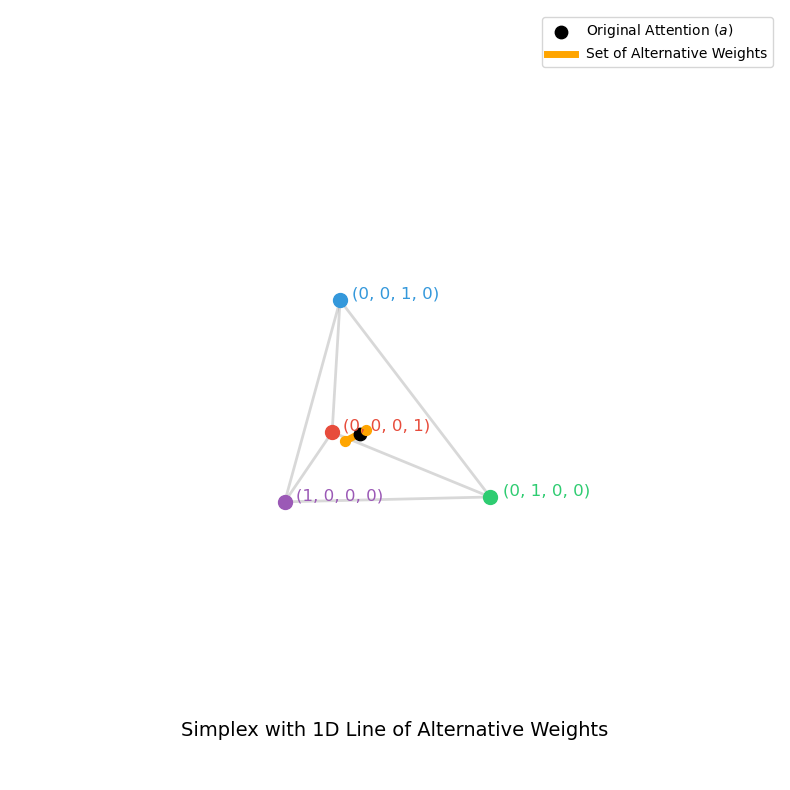

In [23]:
import numpy as np
import scipy.linalg as sc
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Your custom 3D projection points
points_3d = {
    '(1, 0, 0, 0)': np.array([0, 0, -1]),       # Purple (Center/origin-ish)
    '(0, 1, 0, 0)': np.array([1, -0.2, 0]),     # Green (Right)
    '(0, 0, 1, 0)': np.array([0.4, -0.2, 2]),   # Blue (Top)
    '(0, 0, 0, 1)': np.array([-0.6, 1, -1.9])   # Red (Left/Forward)
}

colors = {
    '(1, 0, 0, 0)': '#9b59b6', # Purple
    '(0, 1, 0, 0)': '#2ecc71', # Green
    '(0, 0, 1, 0)': '#3498db', # Blue
    '(0, 0, 0, 1)': '#e74c3c'  # Red
}

# 1. Plot simplex wireframe
vertices = list(points_3d.keys())
for i in range(len(vertices)):
    for j in range(i + 1, len(vertices)):
        p1 = points_3d[vertices[i]]
        p2 = points_3d[vertices[j]]
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], color='gray', linewidth=2, alpha=0.3)

for label, coords in points_3d.items():
    color = colors[label]
    ax.scatter(*coords, color=color, s=100, depthshade=False, zorder=5)
    ax.text(coords[0] + 0.05, coords[1], coords[2] + 0.05, f'{label}', color=color, fontsize=12, zorder=10)

# --- Math & Projection ---
a = np.array([0.25, 0.25, 0.25, 0.25]).reshape(4, 1)
T_aug = np.array([[1.4, 0.2, 1], [0.5, 1.5, 1], [-1.2, 0.9, 1], [0.1, 0.8, 1]])

# 2. Get the 1D Null space
basis_LN = sc.null_space(T_aug.T) # Shape (4, 1)

# 3. Find both max and min lambda to trace the full line segment across the simplex
lam_max_list = []
lam_min_list = []
for idx, val in enumerate(basis_LN):
    if val[0] < 0:
        lam_max_list.append(-a[idx, 0] / val[0])
    elif val[0] > 0:
        lam_min_list.append(-a[idx, 0] / val[0])

lam_max = np.min(lam_max_list)
lam_min = np.max(lam_min_list)

a_max = a + lam_max * basis_LN
a_min = a + lam_min * basis_LN

# 4. Create a Projection Matrix P mapping standard 4D basis to your custom 3D points
P = np.column_stack([points_3d[v] for v in vertices])

# Project points to 3D
a_3d = P @ a
a_max_3d = P @ a_max
a_min_3d = P @ a_min

# 5. Plot original uniform attention
ax.scatter(*a_3d, color='black', s=80, label='Original Attention ($a$)', zorder=6)

# Plot the 1D null space segment (the valid alternative weights)
ax.plot([a_min_3d[0, 0], a_max_3d[0, 0]], 
        [a_min_3d[1, 0], a_max_3d[1, 0]], 
        [a_min_3d[2, 0], a_max_3d[2, 0]], 
        color='orange', linewidth=5, label='Set of Alternative Weights')

ax.scatter(*a_max_3d, color='orange', s=50, marker='o', zorder=6)
ax.scatter(*a_min_3d, color='orange', s=50, marker='o', zorder=6)

ax.set_axis_off()
ax.view_init(elev=20, azim=-60)
plt.title("Simplex with 1D Line of Alternative Weights", y=0.05, fontsize=14)
plt.legend(loc='upper right')
plt.tight_layout()

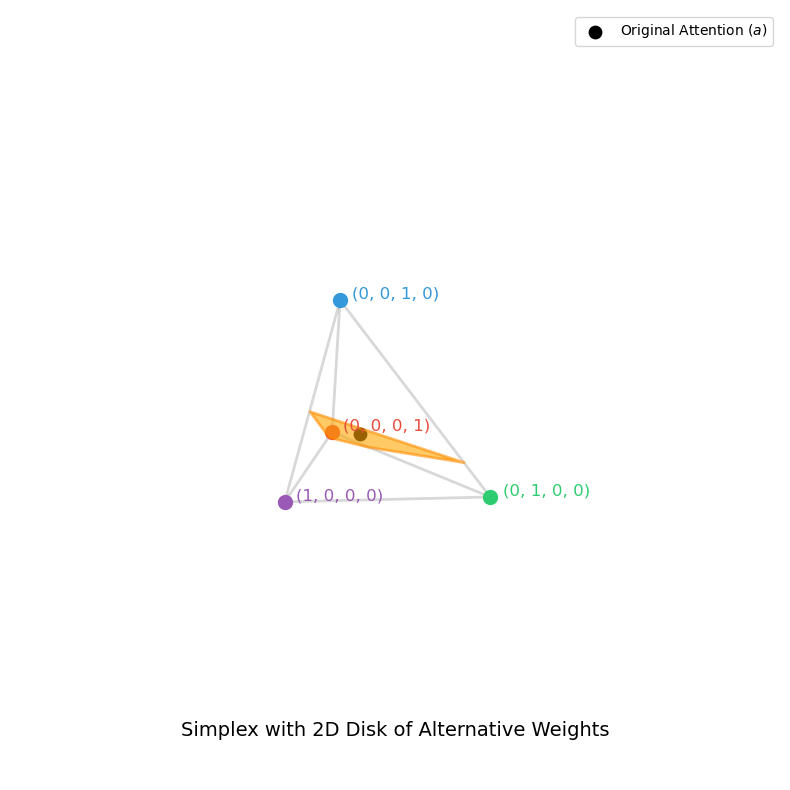

In [5]:
import numpy as np
import scipy.linalg as sc
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import itertools

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

points_3d = {
    '(1, 0, 0, 0)': np.array([0, 0, -1]),       # Purple (Center/origin-ish)
    '(0, 1, 0, 0)': np.array([1, -0.2, 0]),     # Green (Right)
    '(0, 0, 1, 0)': np.array([0.4, -0.2, 2]),   # Blue (Top)
    '(0, 0, 0, 1)': np.array([-0.6, 1, -1.9])   # Red (Left/Forward)
}

colors = {
    '(1, 0, 0, 0)': '#9b59b6', # Purple
    '(0, 1, 0, 0)': '#2ecc71', # Green
    '(0, 0, 1, 0)': '#3498db', # Blue
    '(0, 0, 0, 1)': '#e74c3c'  # Red
}

# 1. Plot simplex wireframe
vertices = list(points_3d.keys())
for i in range(len(vertices)):
    for j in range(i + 1, len(vertices)):
        p1 = points_3d[vertices[i]]
        p2 = points_3d[vertices[j]]
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], color='gray', linewidth=2, alpha=0.3)

for label, coords in points_3d.items():
    color = colors[label]
    ax.scatter(*coords, color=color, s=100, depthshade=False, zorder=5)
    ax.text(coords[0] + 0.05, coords[1], coords[2] + 0.05, f'{label}', color=color, fontsize=12, zorder=10)

# --- Math & Projection ---
a = np.array([0.25, 0.25, 0.25, 0.25]).reshape(4, 1)

# Using just the FIRST column of T to make it 4x1
T = np.array([[1.4], [0.5], [-1.2], [0.1]])
T_aug = np.concatenate([T, np.ones((4, 1))], axis=1) # Shape: (4, 2)

# Get the 2D Null space
basis_LN = sc.null_space(T_aug.T) # Shape: (4, 2)

# Find the polygon vertices in w-space
# We want a + basis_LN @ w >= 0 => basis_LN @ w >= -a
a_vertices_4d = []

for i, j in itertools.combinations(range(4), 2):
    Z_sub = np.array([basis_LN[i], basis_LN[j]])
    a_sub = np.array([-a[i, 0], -a[j, 0]])
    try:
        w = np.linalg.solve(Z_sub, a_sub)
        # Check if the other non-negativity constraints hold
        a_new = a + basis_LN @ w.reshape(2, 1)
        if np.all(a_new >= -1e-7):  # Small numerical tolerance
            a_vertices_4d.append(a_new.flatten())
    except np.linalg.LinAlgError:
        pass # Parallel lines

# Remove duplicates
a_vertices_4d = np.unique(np.round(a_vertices_4d, 6), axis=0)

# Create Projection Matrix P
P = np.column_stack([points_3d[v] for v in vertices])

# Project points to 3D
a_3d = P @ a.flatten()
poly_3d = np.array([P @ a_v for a_v in a_vertices_4d])

# Sort vertices radially to make a valid closed polygon for rendering
center = np.mean(poly_3d, axis=0)
_, _, V = np.linalg.svd(poly_3d - center)
proj_2d = (poly_3d - center) @ V[:2].T
angles = np.arctan2(proj_2d[:, 1], proj_2d[:, 0])
poly_3d = poly_3d[np.argsort(angles)]

# Plot the 2D disk (Polygon) of valid alternative weights
poly = Poly3DCollection([poly_3d], alpha=0.6, facecolor='orange', edgecolor='darkorange', linewidths=2)
ax.add_collection3d(poly)

# Plot original uniform attention
ax.scatter(*a_3d, color='black', s=80, label='Or?iginal Attention ($a$)', zorder=6)

ax.set_axis_off()
ax.view_init(elev=20, azim=-60)
plt.title("Simplex with 2D Disk of Alternative Weights", y=0.05, fontsize=14)
plt.legend(loc='upper right')
plt.tight_layout()

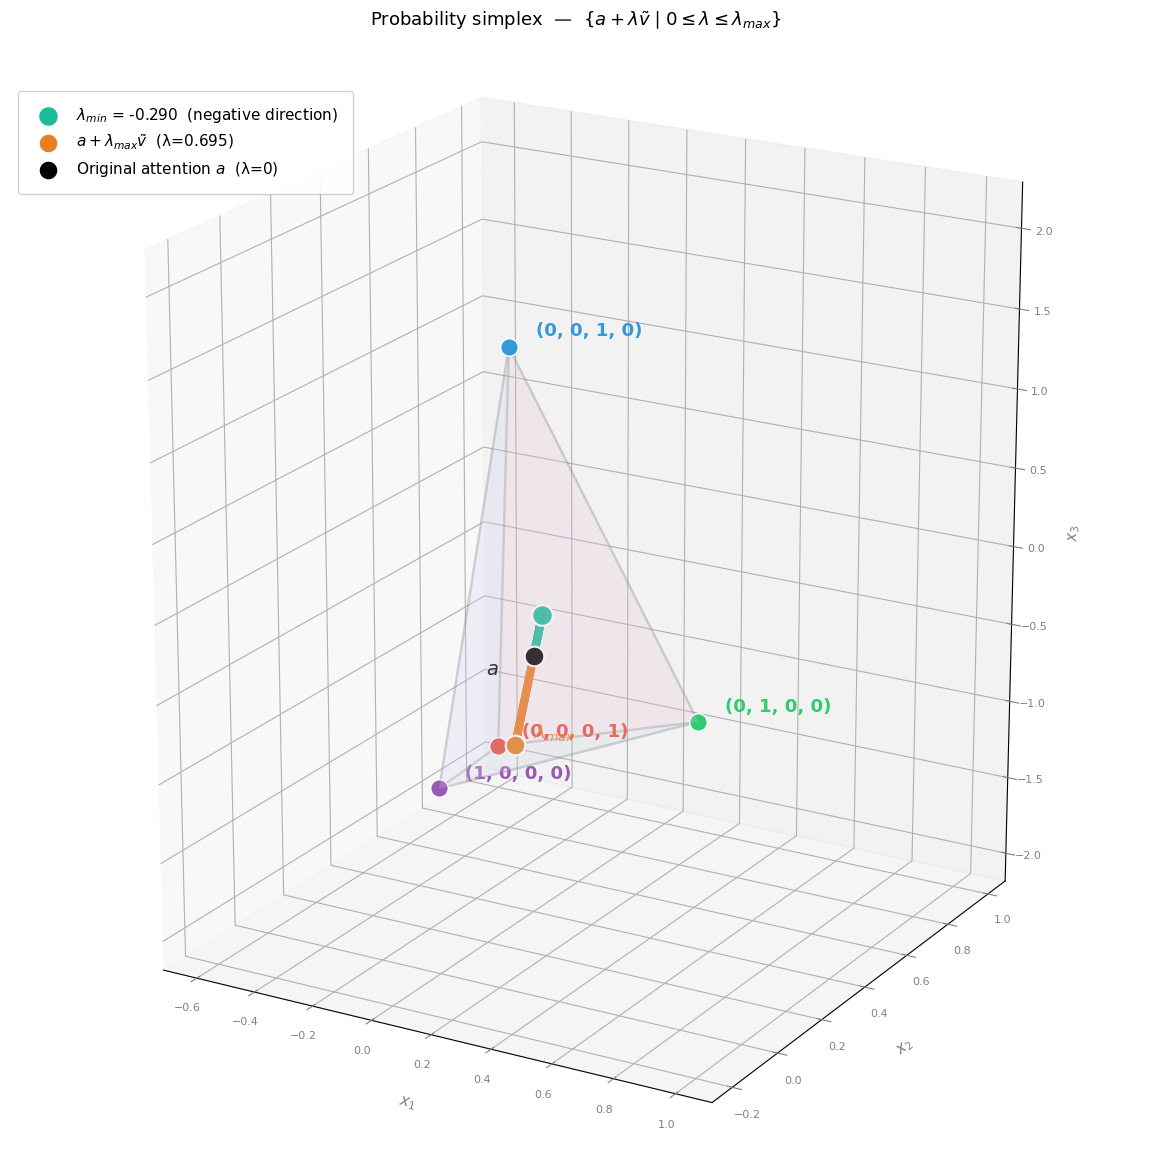

In [25]:
import numpy as np
import scipy.linalg as sc
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

fig = plt.figure(figsize=(14, 12))
ax = fig.add_subplot(111, projection='3d')

points_3d = {
    '(1, 0, 0, 0)': np.array([0, 0, -1]),
    '(0, 1, 0, 0)': np.array([1, -0.2, 0]),
    '(0, 0, 1, 0)': np.array([0.4, -0.2, 2]),
    '(0, 0, 0, 1)': np.array([-0.6, 1, -1.9])
}
colors = {
    '(1, 0, 0, 0)': '#9b59b6',
    '(0, 1, 0, 0)': '#2ecc71',
    '(0, 0, 1, 0)': '#3498db',
    '(0, 0, 0, 1)': '#e74c3c'
}

vertices = list(points_3d.keys())
P = np.column_stack([points_3d[v] for v in vertices])

# Filled faces
face_keys = [
    ['(1, 0, 0, 0)', '(0, 1, 0, 0)', '(0, 0, 1, 0)'],
    ['(1, 0, 0, 0)', '(0, 1, 0, 0)', '(0, 0, 0, 1)'],
    ['(1, 0, 0, 0)', '(0, 0, 1, 0)', '(0, 0, 0, 1)'],
    ['(0, 1, 0, 0)', '(0, 0, 1, 0)', '(0, 0, 0, 1)'],
]
face_colors_list = ['#d5c4f0', '#c4e8d5', '#c4d8f0', '#f5c4c4']
for fk, fc in zip(face_keys, face_colors_list):
    poly = Poly3DCollection([[points_3d[k] for k in fk]], alpha=0.13, facecolor=fc, edgecolor='none')
    ax.add_collection3d(poly)

# Wireframe
for i in range(len(vertices)):
    for j in range(i + 1, len(vertices)):
        p1 = points_3d[vertices[i]]
        p2 = points_3d[vertices[j]]
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], color='gray', linewidth=1.8, alpha=0.35)

# Vertex dots and labels
for label, coords in points_3d.items():
    color = colors[label]
    ax.scatter(*coords, color=color, s=160, depthshade=False, zorder=5, edgecolors='white', linewidths=1)
    ax.text(coords[0]+0.07, coords[1]+0.02, coords[2]+0.07, label, color=color, fontsize=13, fontweight='bold')

a = np.array([0.25, 0.25, 0.25, 0.25]).reshape(4, 1)
T_aug = np.array([[1.4, 0.2, 1], [0.5, 1.5, 1], [-1.2, 0.9, 1], [0.1, 0.8, 1]])
basis_LN = sc.null_space(T_aug.T)

lam_max_list = []
for idx, val in enumerate(basis_LN):
    if val[0] < 0:
        lam_max_list.append(-a[idx, 0] / val[0])
lam_max = np.min(lam_max_list)

a_max    = a + lam_max * basis_LN
a_3d     = P @ a
a_max_3d = P @ a_max

# Gradient line segment
n_seg = 100
for k in range(n_seg):
    t0 = k / n_seg
    t1 = (k + 1) / n_seg
    p0 = a_3d.flatten() + t0 * (a_max_3d.flatten() - a_3d.flatten())
    p1 = a_3d.flatten() + t1 * (a_max_3d.flatten() - a_3d.flatten())
    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]],
            color='#e67e22', linewidth=6, alpha=0.4 + 0.6*t0, solid_capstyle='round')

lam_min_list = []
for idx, val in enumerate(basis_LN):
    if val[0] < 0:
        lam_max_list.append(-a[idx, 0] / val[0])
    elif val[0] > 0:
        lam_min_list.append(-a[idx, 0] / val[0])

lam_min = np.max(lam_min_list) 
a_min = a + lam_min * basis_LN
a_min_3d = P @ a_min

# Negative segment (teal)
for k in range(n_seg):
    t0 = k / n_seg
    t1 = (k + 1) / n_seg
    p0 = a_3d.flatten() + t0 * (a_min_3d.flatten() - a_3d.flatten())
    p1 = a_3d.flatten() + t1 * (a_min_3d.flatten() - a_3d.flatten())
    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]],
            color='#1abc9c', linewidth=6, alpha=0.4 + 0.6*t0, solid_capstyle='round')

ax.scatter(*a_min_3d.flatten(), color='#1abc9c', s=220, marker='o', zorder=8,
           edgecolors='white', linewidths=1.5,
           label=f'$\\lambda_{{min}}$ = {lam_min:.3f}  (negative direction)')

ax.scatter(*a_max_3d.flatten(), color='#e67e22', s=200, marker='o',
           zorder=8, edgecolors='white', linewidths=1.5, label=f'$a + \\lambda_{{max}}\\tilde{{v}}$  (λ={lam_max:.3f})')
ax.scatter(*a_3d.flatten(), color='black', s=200, marker='o',
           zorder=9, edgecolors='white', linewidths=1.5, label='Original attention $a$  (λ=0)')

ax.text(a_3d[0,0]-0.12, a_3d[1,0]-0.05, a_3d[2,0]-0.12, '$a$', fontsize=14, color='black', fontweight='bold')
ax.text(a_max_3d[0,0]+0.05, a_max_3d[1,0]+0.02, a_max_3d[2,0]+0.05, '$\\lambda_{max}$', fontsize=13, color='#e67e22', fontweight='bold')

ax.set_xlabel('$x_1$', fontsize=11, labelpad=10, color='gray')
ax.set_ylabel('$x_2$', fontsize=11, labelpad=10, color='gray')
ax.set_zlabel('$x_3$', fontsize=11, labelpad=10, color='gray')
ax.tick_params(colors='gray', labelsize=8)
ax.view_init(elev=20, azim=-60)
ax.set_box_aspect([1, 1, 1.2])
ax.legend(loc='upper left', fontsize=11, framealpha=0.9, bbox_to_anchor=(0.0, 0.95), borderpad=1)

fig.suptitle('Probability simplex  —  $\\{a + \\lambda\\tilde{v}\\mid 0 \\leq \\lambda \\leq \\lambda_{max}\\}$', fontsize=13, y=0.97)
plt.tight_layout()
plt.savefig('simplex_1d_full.png', dpi=180, bbox_inches='tight')
plt.show()